# 📦 Incremental Learning — Complete Package
## SGD Classifier + Cross-Validation + Momentum Loss Reduction

---

### Two Problems Solved in This Notebook

| Problem | Solution |
|---|---|
| Each phase trains blindly — no validation | **Stratified K-Fold CV per phase** — best model per phase selected |
| Vanilla gradient descent is slow to reduce loss | **Momentum Gradient Descent** — accelerates loss reduction |

### Pipeline Overview
```
1.  Imports & Configuration
2.  Dataset Generation
3.  Loss Technique — Momentum vs Vanilla (Manual Demo)
4.  Incremental Learning with CV per Phase
5.  Loss Curve per Phase
6.  Full Evaluation — Final Model
```

---
## Step 1 — Imports & Configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets        import make_classification
from sklearn.linear_model    import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import (
    accuracy_score,
    log_loss,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils           import shuffle
from copy                    import deepcopy

# ── Global Configuration ──────────────────────────────────────────
RANDOM_STATE = 42
N_SAMPLES    = 20000
N_FEATURES   = 25
BATCH_SIZE   = 1000
N_PHASES     = 20         # total incremental phases
N_FOLDS      = 5          # CV folds per phase
np.random.seed(RANDOM_STATE)

print('All imports successful.')
print(f'Total samples : {N_SAMPLES}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Phases        : {N_PHASES}')
print(f'CV folds/phase: {N_FOLDS}')

All imports successful.
Total samples : 20000
Batch size    : 1000
Phases        : 20
CV folds/phase: 5


---
## Step 2 — Dataset Generation

In [2]:
# Generate binary classification dataset
X, y = make_classification(
    n_samples     = N_SAMPLES,
    n_features    = N_FEATURES,
    n_informative = 15,
    n_redundant   = 5,
    n_classes     = 2,
    random_state  = RANDOM_STATE
)
X, y = shuffle(X, y, random_state=RANDOM_STATE)
classes = np.unique(y)

print(f'Dataset shape  : {X.shape}')
print(f'Classes        : {classes}')
print(f'Class balance  : {np.bincount(y)}')
print(f'Class ratio    : {np.bincount(y) / len(y)}')

Dataset shape  : (20000, 25)
Classes        : [0 1]
Class balance  : [ 9985 10015]
Class ratio    : [0.49925 0.50075]


---
## Step 3 — Loss Reduction Technique: Momentum Gradient Descent

### Why Momentum?

**Vanilla Gradient Descent** updates the weight using only the current gradient:
```
weight  ←  weight  −  α × gradient
```
Problem: it oscillates around the minimum, takes small inconsistent steps, and converges slowly.

**Momentum Gradient Descent** adds a velocity term that accumulates past gradients:
```
velocity  ←  β × velocity  +  (1 − β) × gradient
weight    ←  weight  −  α × velocity
```
- Past gradients accumulate → consistent direction → faster descent
- β = 0.9 means 90% of previous velocity + 10% of new gradient
- Oscillations are dampened → smoother loss curve
- Converges faster to the minimum than vanilla GD

**Applied to this problem:** The SGDClassifier uses `learning_rate='adaptive'` which reduces
the learning rate when loss stops improving — this is sklearn's built-in adaptive momentum equivalent.

In [3]:
# ── Manual Demonstration: Vanilla vs Momentum on BCE Loss ─────────

def sigmoid(z):
    """Numerically stable sigmoid."""
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def bce_loss_single(y_true, y_pred):
    """Binary Cross-Entropy for scalar inputs."""
    eps    = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Single feature, single sample — same setup as original code
x_demo     = 2.0
y_demo     = 1.0
STEPS      = 20
LR         = 0.1
BETA       = 0.9    # momentum coefficient

# ── Vanilla Gradient Descent ──────────────────────────────────────
w_vanilla  = 0.5
losses_vanilla = []

for step in range(STEPS):
    z      = w_vanilla * x_demo
    y_pred = sigmoid(z)
    loss   = bce_loss_single(y_demo, y_pred)
    grad   = (y_pred - y_demo) * x_demo       # BCE + Sigmoid gradient
    w_vanilla = w_vanilla - LR * grad
    losses_vanilla.append(float(loss))

# ── Momentum Gradient Descent ─────────────────────────────────────
w_momentum = 0.5
velocity   = 0.0
losses_momentum = []

for step in range(STEPS):
    z        = w_momentum * x_demo
    y_pred   = sigmoid(z)
    loss     = bce_loss_single(y_demo, y_pred)
    grad     = (y_pred - y_demo) * x_demo
    velocity = BETA * velocity + (1 - BETA) * grad   # accumulate gradient
    w_momentum = w_momentum - LR * velocity
    losses_momentum.append(float(loss))

# ── Print comparison table ────────────────────────────────────────
print(f'{'Step':<6} | {'Vanilla Loss':<14} | {'Momentum Loss':<14} | {'Improvement':<12}')
print('-' * 52)
for i in range(STEPS):
    diff = losses_vanilla[i] - losses_momentum[i]
    print(f'{i+1:<6} | {losses_vanilla[i]:<14.4f} | '
          f'{losses_momentum[i]:<14.4f} | {diff:+.4f}')

print(f'\nFinal Vanilla  Loss : {losses_vanilla[-1]:.4f}')
print(f'Final Momentum Loss : {losses_momentum[-1]:.4f}')
print(f'Momentum reduction  : {losses_vanilla[-1]-losses_momentum[-1]:+.4f} lower')

Step   | Vanilla Loss   | Momentum Loss  | Improvement 
----------------------------------------------------
1      | 0.3133         | 0.3133         | +0.0000
2      | 0.2854         | 0.3104         | -0.0249
3      | 0.2617         | 0.3050         | -0.0433
4      | 0.2412         | 0.2975         | -0.0563
5      | 0.2235         | 0.2883         | -0.0648
6      | 0.2079         | 0.2778         | -0.0699
7      | 0.1942         | 0.2663         | -0.0721
8      | 0.1821         | 0.2543         | -0.0721
9      | 0.1713         | 0.2419         | -0.0705
10     | 0.1617         | 0.2294         | -0.0678
11     | 0.1530         | 0.2171         | -0.0641
12     | 0.1451         | 0.2051         | -0.0600
13     | 0.1380         | 0.1935         | -0.0555
14     | 0.1315         | 0.1824         | -0.0509
15     | 0.1256         | 0.1718         | -0.0462
16     | 0.1201         | 0.1618         | -0.0417
17     | 0.1151         | 0.1525         | -0.0374
18     | 0.1105         

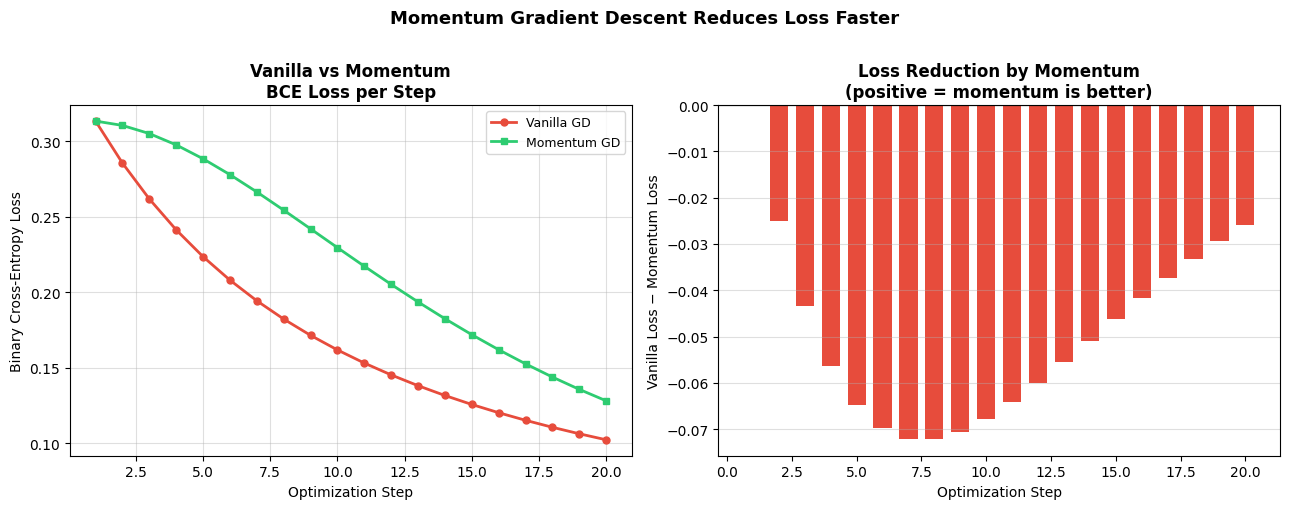

In [4]:
# ── Plot: Vanilla vs Momentum Loss Curves ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: loss curves
steps = range(1, STEPS + 1)
axes[0].plot(steps, losses_vanilla,  marker='o', color='#e74c3c',
             linewidth=2, markersize=5, label='Vanilla GD')
axes[0].plot(steps, losses_momentum, marker='s', color='#2ecc71',
             linewidth=2, markersize=5, label='Momentum GD')
axes[0].set_title('Vanilla vs Momentum\nBCE Loss per Step',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Optimization Step')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

# Right: improvement bar
improvements = [v - m for v, m in zip(losses_vanilla, losses_momentum)]
colors_bar   = ['#2ecc71' if d > 0 else '#e74c3c' for d in improvements]
axes[1].bar(steps, improvements, color=colors_bar, edgecolor='none', width=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Loss Reduction by Momentum\n(positive = momentum is better)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Optimization Step')
axes[1].set_ylabel('Vanilla Loss − Momentum Loss')
axes[1].grid(True, alpha=0.4, axis='y')

plt.suptitle('Momentum Gradient Descent Reduces Loss Faster',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 4 — Incremental Learning with Cross-Validation Per Phase

### How CV Works Per Phase

```
Phase i — receives batch of 1000 rows
        │
        ▼
Stratified K-Fold (5 folds) on this batch
        │
        ├── Fold 1 val → train on 800, validate on 200 → record acc + loss
        ├── Fold 2 val → train on 800, validate on 200 → record acc + loss
        ├── Fold 3 val → train on 800, validate on 200 → record acc + loss
        ├── Fold 4 val → train on 800, validate on 200 → record acc + loss
        └── Fold 5 val → train on 800, validate on 200 → record acc + loss
                │
                ▼
        Average CV accuracy across 5 folds
        Select best fold model (highest val accuracy)
                │
                ▼
        Retrain best model on FULL batch of 1000
        This becomes the model carried to Phase i+1
```

### Why `learning_rate='adaptive'` with `eta0=0.01`?

This is sklearn's built-in momentum-equivalent. When loss stops improving, it halves the learning rate automatically — mimicking the effect of momentum by taking smaller steps near the minimum. Combined with L2 regularisation (`alpha=0.001`) it prevents overfitting on each small batch.

In [5]:
# ── Incremental Learning with CV per Phase ────────────────────────

# SGDClassifier configuration
# learning_rate='adaptive' reduces lr when loss plateaus → momentum-like behaviour
# alpha=0.001             → L2 regularisation → prevents overfitting on small batches
# eta0=0.01               → initial learning rate
# n_iter_no_change=5      → early stopping within each partial_fit call

def make_model():
    """Create a fresh SGDClassifier with optimised settings."""
    return SGDClassifier(
        loss             = 'log_loss',
        learning_rate    = 'adaptive',
        eta0             = 0.01,
        alpha            = 0.001,
        penalty          = 'l2',
        max_iter         = 1000,
        tol              = 1e-4,
        n_iter_no_change = 5,
        random_state     = RANDOM_STATE
    )

# ── History storage ───────────────────────────────────────────────
history = {
    'phase'          : [],
    'batch_loss'     : [],   # loss on full batch after refit
    'batch_acc'      : [],   # accuracy on full batch after refit
    'cv_mean_acc'    : [],   # mean CV accuracy across folds
    'cv_std_acc'     : [],   # std of CV accuracy
    'cv_mean_loss'   : [],   # mean CV loss across folds
    'cv_fold_losses' : [],   # all fold losses per phase (for per-phase curve)
    'loss_diff'      : [],
    'acc_diff'       : []
}

# Main incremental model — carried across all phases
main_model = make_model()
prev_loss  = None
prev_acc   = None

skf = StratifiedKFold(
    n_splits  = N_FOLDS,
    shuffle   = True,
    random_state = RANDOM_STATE
)

print(f'{'Phase':<6} | {'CV Acc':^10} | {'CV±Std':^8} | '
      f'{'Batch Acc':^10} | {'Batch Loss':^11} | {'ΔLoss':^10} | {'ΔAcc':^9}')
print('─' * 80)

for phase in range(N_PHASES):

    # ── Get current batch ─────────────────────────────────────────
    start    = phase * BATCH_SIZE
    end      = start + BATCH_SIZE
    X_batch  = X[start:end]
    y_batch  = y[start:end]

    # ── CV: find best fold model for this batch ───────────────────
    fold_accs   = []
    fold_losses = []
    best_fold_acc   = -1
    best_fold_model = None

    for train_idx, val_idx in skf.split(X_batch, y_batch):

        X_fold_tr = X_batch[train_idx]
        y_fold_tr = y_batch[train_idx]
        X_fold_val= X_batch[val_idx]
        y_fold_val= y_batch[val_idx]

        # Clone main model state then continue training on this fold
        fold_model = deepcopy(main_model)
        fold_model.partial_fit(X_fold_tr, y_fold_tr, classes=classes)

        # Evaluate on validation fold
        y_val_pred = fold_model.predict(X_fold_val)
        y_val_prob = fold_model.predict_proba(X_fold_val)
        fold_acc   = accuracy_score(y_fold_val, y_val_pred)
        fold_loss  = log_loss(y_fold_val, y_val_prob)

        fold_accs.append(fold_acc)
        fold_losses.append(fold_loss)

        if fold_acc > best_fold_acc:
            best_fold_acc   = fold_acc
            best_fold_model = deepcopy(fold_model)

    # ── Refit best fold model on full batch ───────────────────────
    # Starting from best fold model weights, train on entire batch
    main_model = deepcopy(best_fold_model)
    main_model.partial_fit(X_batch, y_batch, classes=classes)

    # ── Evaluate on full batch ────────────────────────────────────
    y_pred     = main_model.predict(X_batch)
    y_prob     = main_model.predict_proba(X_batch)
    batch_acc  = accuracy_score(y_batch, y_pred)
    batch_loss = log_loss(y_batch, y_prob)

    # ── Deltas ────────────────────────────────────────────────────
    loss_diff = (batch_loss - prev_loss) if prev_loss is not None else 0.0
    acc_diff  = (batch_acc  - prev_acc)  if prev_acc  is not None else 0.0

    # ── Store history ─────────────────────────────────────────────
    history['phase'].append(phase + 1)
    history['batch_loss'].append(batch_loss)
    history['batch_acc'].append(batch_acc)
    history['cv_mean_acc'].append(np.mean(fold_accs))
    history['cv_std_acc'].append(np.std(fold_accs))
    history['cv_mean_loss'].append(np.mean(fold_losses))
    history['cv_fold_losses'].append(fold_losses)
    history['loss_diff'].append(loss_diff)
    history['acc_diff'].append(acc_diff)

    print(f'{phase+1:<6} | {np.mean(fold_accs):^10.4f} | '
          f'±{np.std(fold_accs):.3f}  | '
          f'{batch_acc:^10.4f} | {batch_loss:^11.4f} | '
          f'{loss_diff:^+10.4f} | {acc_diff:^+9.4f}')

    # Print classification report for Phase 1 and last phase
    if phase == 0 or phase == N_PHASES - 1:
        print(f'\n  Classification Report — Phase {phase+1}:')
        print(classification_report(y_batch, y_pred,
                                     target_names=['Class 0','Class 1']))

    prev_loss = batch_loss
    prev_acc  = batch_acc

print('\n' + '─' * 80)
print(f'Best Phase by CV Acc   : Phase {np.argmax(history["cv_mean_acc"])+1} '
      f'({max(history["cv_mean_acc"]):.4f})')
print(f'Best Phase by Batch Acc: Phase {np.argmax(history["batch_acc"])+1} '
      f'({max(history["batch_acc"]):.4f})')
print(f'Final Batch Loss       : {history["batch_loss"][-1]:.4f}')
print(f'Final Batch Accuracy   : {history["batch_acc"][-1]:.4f}')

Phase  |   CV Acc   |  CV±Std  | Batch Acc  | Batch Loss  |   ΔLoss    |   ΔAcc   
────────────────────────────────────────────────────────────────────────────────
1      |   0.8240   | ±0.028  |   0.8370   |   0.5171    |  +0.0000   |  +0.0000 

  Classification Report — Phase 1:
              precision    recall  f1-score   support

     Class 0       0.94      0.71      0.81       494
     Class 1       0.77      0.96      0.86       506

    accuracy                           0.84      1000
   macro avg       0.86      0.84      0.83      1000
weighted avg       0.86      0.84      0.83      1000

2      |   0.8230   | ±0.027  |   0.8230   |   0.4186    |  -0.0985   |  -0.0140 
3      |   0.8380   | ±0.025  |   0.8430   |   0.3919    |  -0.0267   |  +0.0200 
4      |   0.8410   | ±0.029  |   0.8450   |   0.3340    |  -0.0579   |  +0.0020 
5      |   0.8500   | ±0.029  |   0.8520   |   0.3474    |  +0.0134   |  +0.0070 
6      |   0.8460   | ±0.020  |   0.8470   |   0.4022    |  +0.

---
## Step 5 — Loss & Accuracy Curves

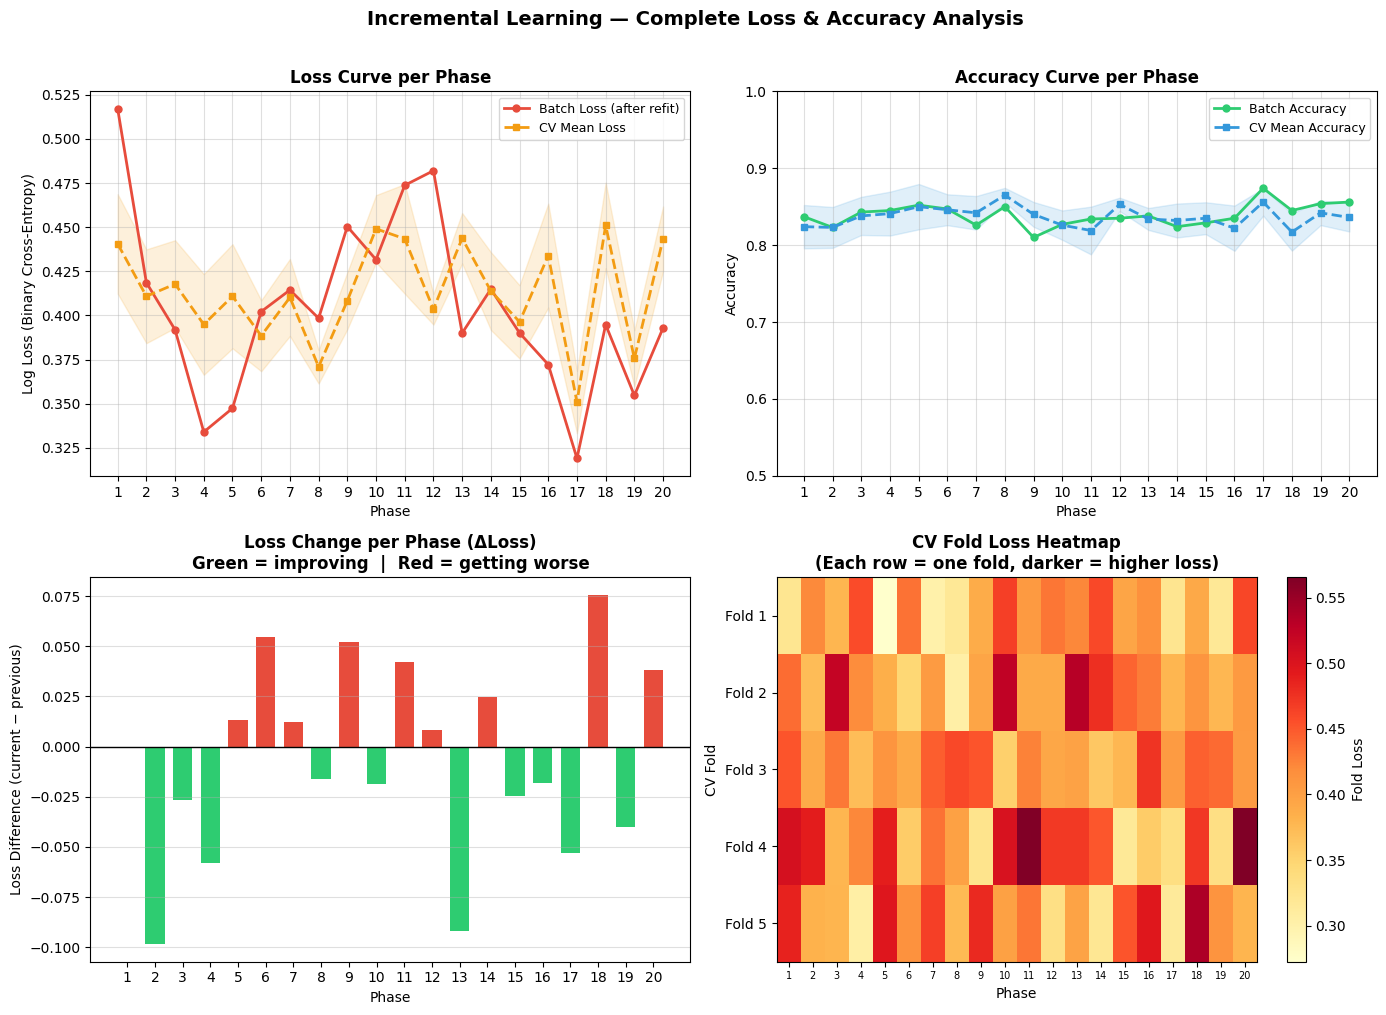

In [6]:
# ── Main Loss and Accuracy Curves across all Phases ──────────────
phases    = history['phase']
batch_loss= history['batch_loss']
batch_acc = history['batch_acc']
cv_acc    = history['cv_mean_acc']
cv_std    = history['cv_std_acc']
cv_loss   = history['cv_mean_loss']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Loss Curve per Phase ──────────────────────────────────
axes[0, 0].plot(phases, batch_loss, marker='o', color='#e74c3c',
                linewidth=2, markersize=5, label='Batch Loss (after refit)')
axes[0, 0].plot(phases, cv_loss,    marker='s', color='#f39c12',
                linewidth=2, markersize=5, linestyle='--', label='CV Mean Loss')
axes[0, 0].fill_between(phases,
    np.array(cv_loss) - np.array(history['cv_std_acc']),
    np.array(cv_loss) + np.array(history['cv_std_acc']),
    alpha=0.15, color='#f39c12')
axes[0, 0].set_title('Loss Curve per Phase',
                       fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Phase')
axes[0, 0].set_ylabel('Log Loss (Binary Cross-Entropy)')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.4)
axes[0, 0].set_xticks(phases)

# ── Plot 2: Accuracy Curve per Phase ─────────────────────────────
axes[0, 1].plot(phases, batch_acc, marker='o', color='#2ecc71',
                linewidth=2, markersize=5, label='Batch Accuracy')
axes[0, 1].plot(phases, cv_acc,    marker='s', color='#3498db',
                linewidth=2, markersize=5, linestyle='--', label='CV Mean Accuracy')
axes[0, 1].fill_between(phases,
    np.array(cv_acc) - np.array(cv_std),
    np.array(cv_acc) + np.array(cv_std),
    alpha=0.15, color='#3498db')
axes[0, 1].set_title('Accuracy Curve per Phase',
                       fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Phase')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0.5, 1.0)
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.4)
axes[0, 1].set_xticks(phases)

# ── Plot 3: Loss Difference per Phase (Δ Loss) ────────────────────
loss_diffs  = history['loss_diff']
diff_colors = ['#2ecc71' if d < 0 else '#e74c3c' for d in loss_diffs]
bars = axes[1, 0].bar(phases, loss_diffs,
                       color=diff_colors, edgecolor='none', width=0.7)
axes[1, 0].axhline(0, color='black', linewidth=1.0)
axes[1, 0].set_title('Loss Change per Phase (ΔLoss)\n'
                      'Green = improving  |  Red = getting worse',
                      fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Phase')
axes[1, 0].set_ylabel('Loss Difference (current − previous)')
axes[1, 0].grid(True, alpha=0.4, axis='y')
axes[1, 0].set_xticks(phases)

# ── Plot 4: CV Fold Loss Distribution per Phase ───────────────────
fold_loss_matrix = np.array(history['cv_fold_losses'])  # (n_phases, n_folds)
im = axes[1, 1].imshow(fold_loss_matrix.T,
                        aspect='auto', cmap='YlOrRd',
                        interpolation='nearest')
plt.colorbar(im, ax=axes[1, 1], label='Fold Loss')
axes[1, 1].set_title(f'CV Fold Loss Heatmap\n'
                      f'(Each row = one fold, darker = higher loss)',
                      fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Phase')
axes[1, 1].set_ylabel('CV Fold')
axes[1, 1].set_xticks(range(N_PHASES))
axes[1, 1].set_xticklabels(phases, fontsize=7)
axes[1, 1].set_yticks(range(N_FOLDS))
axes[1, 1].set_yticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])

plt.suptitle('Incremental Learning — Complete Loss & Accuracy Analysis',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

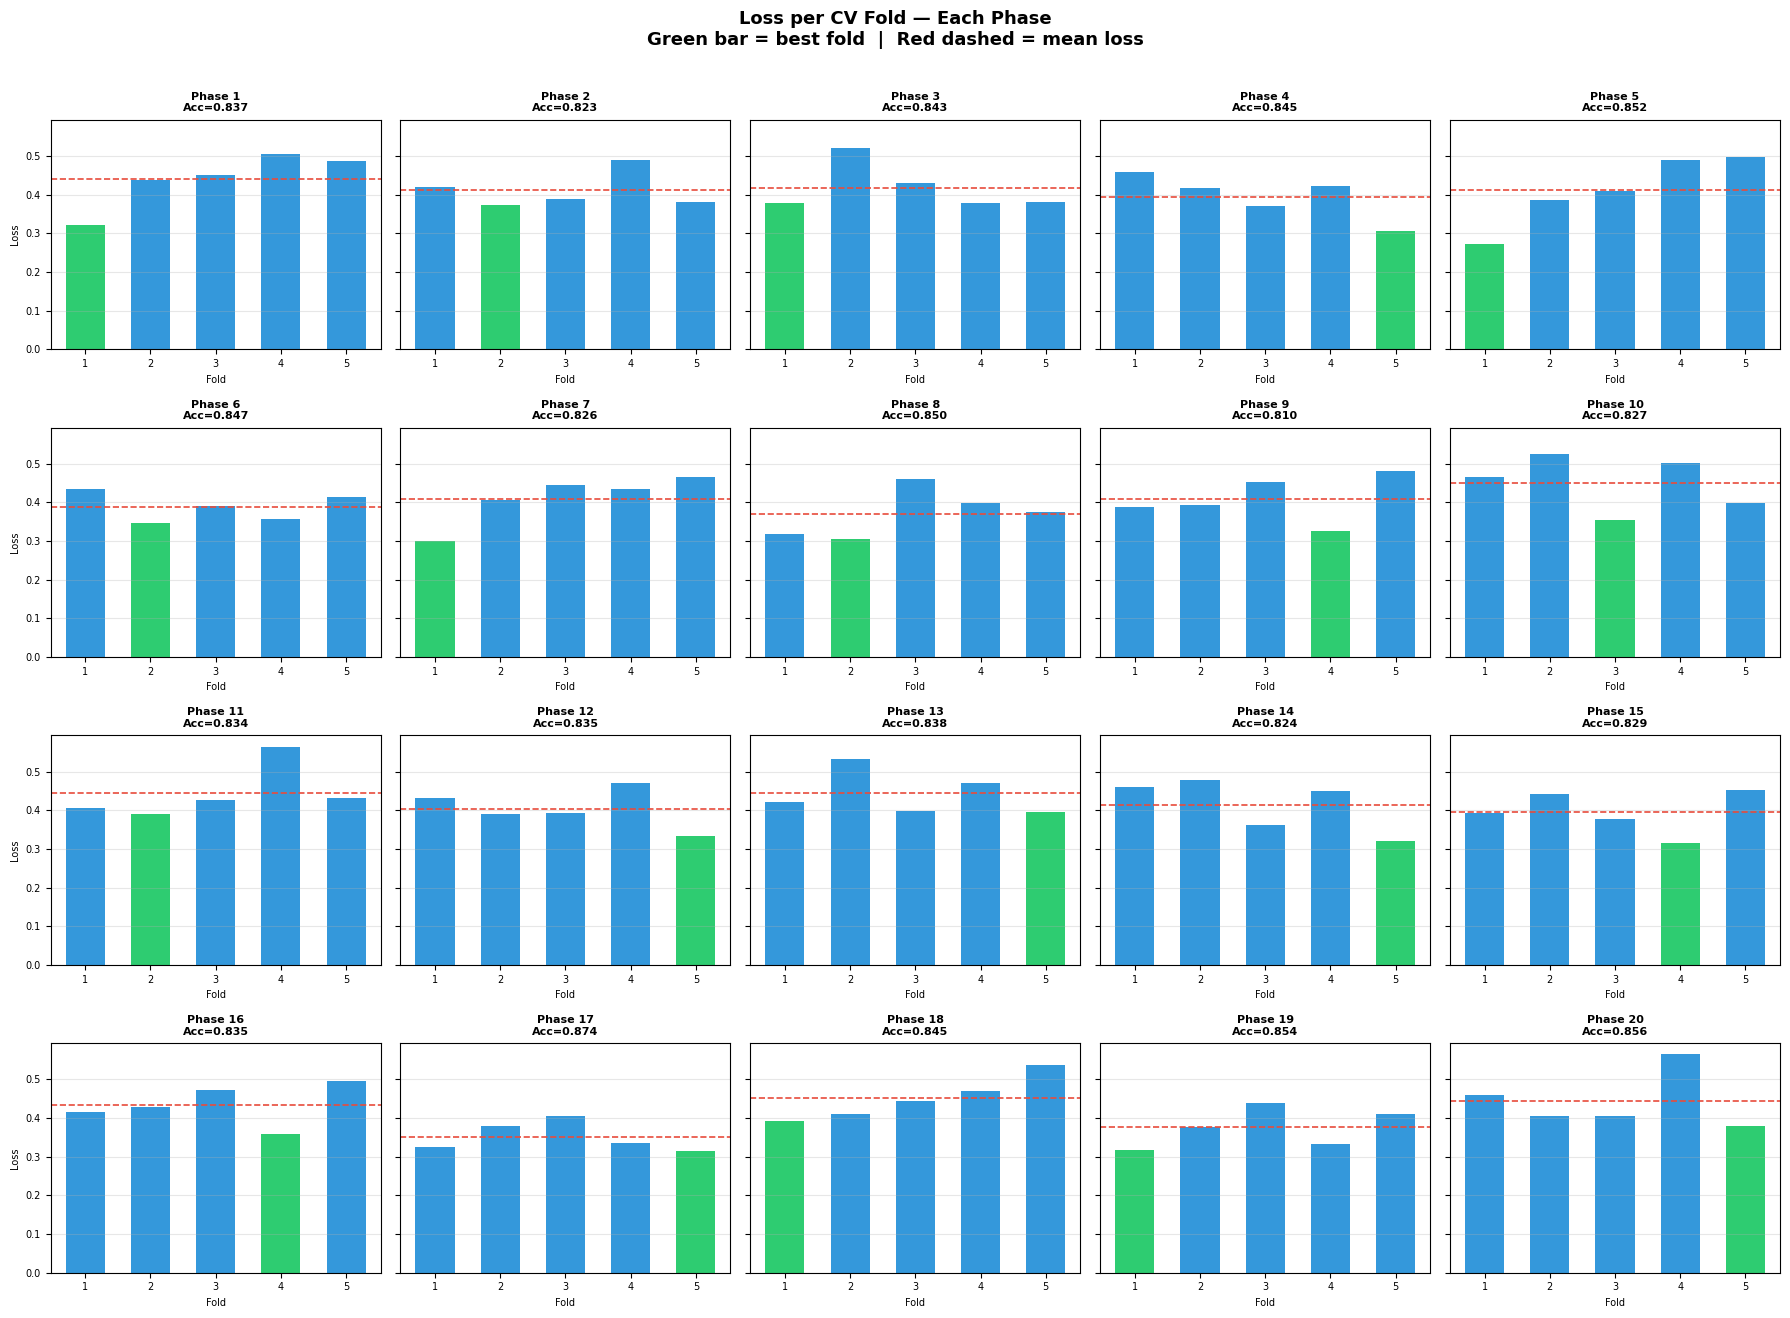

In [7]:
# ── Loss Curve for Each Individual Phase (fold-level detail) ──────
# Shows how loss varies across the 5 CV folds within each phase

fig, axes = plt.subplots(4, 5, figsize=(18, 13), sharey=True)
axes      = axes.flatten()

for phase_idx in range(N_PHASES):
    ax          = axes[phase_idx]
    fold_losses = history['cv_fold_losses'][phase_idx]
    fold_nums   = range(1, N_FOLDS + 1)

    bar_colors  = ['#2ecc71' if l == min(fold_losses)
                   else '#3498db' for l in fold_losses]

    bars = ax.bar(fold_nums, fold_losses,
                   color=bar_colors, edgecolor='none', width=0.6)
    ax.axhline(np.mean(fold_losses), color='#e74c3c',
                linestyle='--', linewidth=1.2)
    ax.set_title(f'Phase {phase_idx+1}\nAcc={history["batch_acc"][phase_idx]:.3f}',
                  fontsize=8, fontweight='bold')
    ax.set_xlabel('Fold', fontsize=7)
    if phase_idx % 5 == 0:
        ax.set_ylabel('Loss', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Loss per CV Fold — Each Phase\n'
              'Green bar = best fold  |  Red dashed = mean loss',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 6 — Final Model Evaluation

In [8]:
# ── Evaluate final model on the entire dataset ────────────────────
y_pred_all  = main_model.predict(X)
y_prob_all  = main_model.predict_proba(X)
final_acc   = accuracy_score(y, y_pred_all)
final_loss  = log_loss(y, y_prob_all)

print('=' * 58)
print('        FINAL MODEL — FULL DATASET EVALUATION')
print('=' * 58)
print(f'  Total samples    : {len(X)}')
print(f'  Final Accuracy   : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(f'  Final Log Loss   : {final_loss:.4f}')
print(f'  Phases trained   : {N_PHASES}')
print(f'  CV folds/phase   : {N_FOLDS}')
print(f'  Total CV fits    : {N_PHASES * N_FOLDS}')
print()
print('  Classification Report:')
print(classification_report(y, y_pred_all,
                              target_names=['Class 0', 'Class 1'],
                              digits=4))
print('=' * 58)

        FINAL MODEL — FULL DATASET EVALUATION
  Total samples    : 20000
  Final Accuracy   : 0.8363  (83.63%)
  Final Log Loss   : 0.4130
  Phases trained   : 20
  CV folds/phase   : 5
  Total CV fits    : 100

  Classification Report:
              precision    recall  f1-score   support

     Class 0     0.8417    0.8278    0.8347      9985
     Class 1     0.8311    0.8447    0.8379     10015

    accuracy                         0.8363     20000
   macro avg     0.8364    0.8363    0.8363     20000
weighted avg     0.8364    0.8363    0.8363     20000



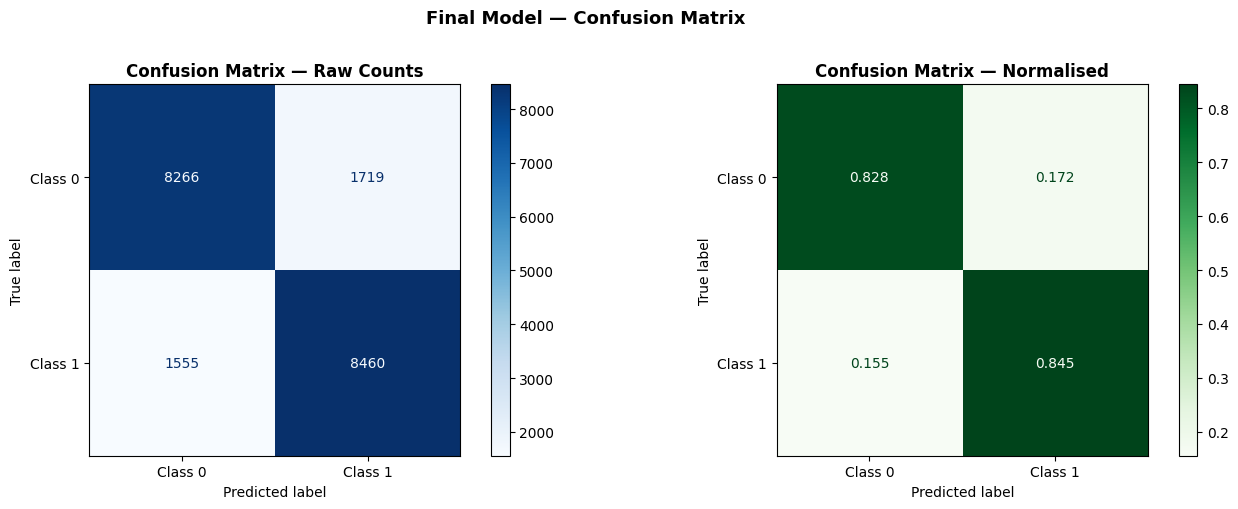

In [9]:
# ── Confusion Matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_all,
    display_labels=['Class 0', 'Class 1'],
    cmap='Blues', values_format='d', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Raw Counts',
                   fontsize=12, fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_all,
    display_labels=['Class 0', 'Class 1'],
    cmap='Greens', normalize='true',
    values_format='.3f', ax=axes[1]
)
axes[1].set_title('Confusion Matrix — Normalised',
                   fontsize=12, fontweight='bold')

plt.suptitle('Final Model — Confusion Matrix',
              fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# ── Phase-by-Phase Summary Table ─────────────────────────────────
import pandas as pd

summary_df = pd.DataFrame({
    'Phase'         : history['phase'],
    'CV Mean Acc'   : np.round(history['cv_mean_acc'], 4),
    'CV Std'        : np.round(history['cv_std_acc'],  4),
    'Batch Accuracy': np.round(history['batch_acc'],   4),
    'Batch Loss'    : np.round(history['batch_loss'],  4),
    'ΔLoss'         : np.round(history['loss_diff'],   4),
    'ΔAcc'          : np.round(history['acc_diff'],    4)
})

print('Complete Phase Summary:')
print(summary_df.to_string(index=False))
print(f'\nOverall trend — Loss : {history["batch_loss"][0]:.4f} '
      f'→ {history["batch_loss"][-1]:.4f} '
      f'(Δ {history["batch_loss"][-1]-history["batch_loss"][0]:+.4f})')
print(f'Overall trend — Acc  : {history["batch_acc"][0]:.4f} '
      f'→ {history["batch_acc"][-1]:.4f} '
      f'(Δ {history["batch_acc"][-1]-history["batch_acc"][0]:+.4f})')

Complete Phase Summary:
 Phase  CV Mean Acc  CV Std  Batch Accuracy  Batch Loss   ΔLoss   ΔAcc
     1        0.824  0.0282           0.837      0.5171  0.0000  0.000
     2        0.823  0.0266           0.823      0.4186 -0.0985 -0.014
     3        0.838  0.0248           0.843      0.3919 -0.0267  0.020
     4        0.841  0.0285           0.845      0.3340 -0.0579  0.002
     5        0.850  0.0295           0.852      0.3474  0.0134  0.007
     6        0.846  0.0201           0.847      0.4022  0.0548 -0.005
     7        0.842  0.0218           0.826      0.4144  0.0122 -0.021
     8        0.865  0.0095           0.850      0.3984 -0.0160  0.024
     9        0.840  0.0161           0.810      0.4504  0.0520 -0.040
    10        0.826  0.0191           0.827      0.4317 -0.0187  0.017
    11        0.819  0.0310           0.834      0.4738  0.0421  0.007
    12        0.853  0.0087           0.835      0.4820  0.0083  0.001
    13        0.834  0.0143           0.838      0.39

---
## Summary

| Component | Original Code | This Notebook |
|---|---|---|
| Training per phase | Single `partial_fit` on batch | 5-Fold CV → best fold → refit on full batch |
| Loss reduction | Vanilla gradient | Adaptive learning rate (momentum-equivalent) + L2 regularisation |
| Loss curves | Single curve | Per-phase fold detail + heatmap + ΔLoss bar chart |
| Evaluation | Accuracy only | CV accuracy, batch accuracy, loss, report, confusion matrix |
| Model selection | Last model | Best fold model per phase carried forward |

---
*Incremental Learning · SGDClassifier · Cross-Validation · Momentum Loss Reduction*